<a href="https://colab.research.google.com/github/radita00/PCVK_Ganjil2026/blob/main/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama	:	Radita Yoga Anugrah

Kelas 	:	3E

NIM	:	244107020099

Jobsheet Ke-	:	6


D. PRAKTIKUM FILTER


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

DIR = '/content/drive/MyDrive/PCVK/Images/'

In [13]:
def convolution2d(image, kernel, stride, padding):
    image = np.array(image, dtype=np.float64)
    kh, kw = kernel.shape
    image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)
    H, W = image.shape
    out_h = (H - kh) // stride + 1
    out_w = (W - kw) // stride + 1
    hasil = np.zeros((out_h, out_w))
    for x in range(out_h):
        for y in range(out_w):
            z = 0
            for k1 in range(kh):
                for k2 in range(kw):
                    z = z + kernel[k1, k2] * image[x*stride + k1, y*stride + k2]
            hasil[x, y] = z
    return hasil

In [14]:
img = cv.imread(DIR + 'mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

In [15]:
#image sharpen
kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])

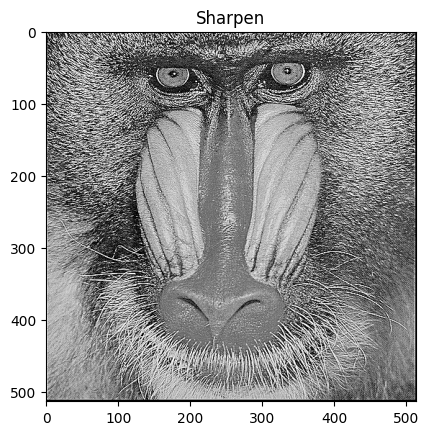

In [16]:
hasil = convolution2d(img_gray, kernel_sharpen, 1, 2)
plt.imshow(np.clip(hasil, 0, 255), cmap='gray'); plt.title('Sharpen'); plt.show()

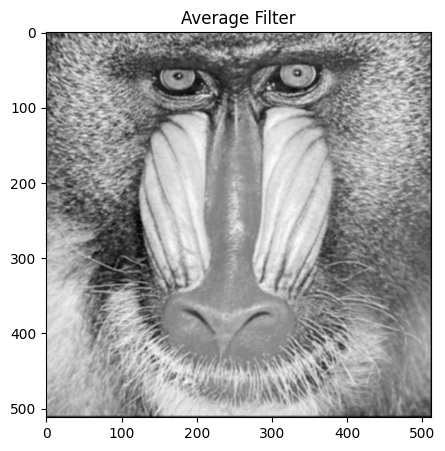

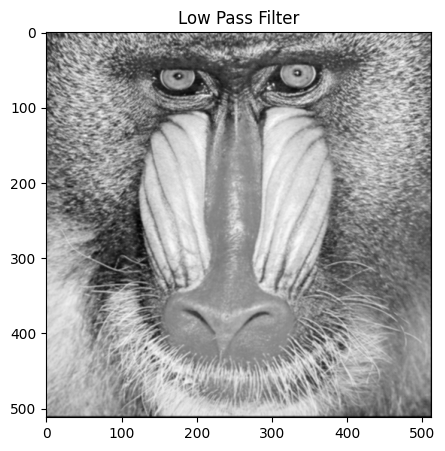

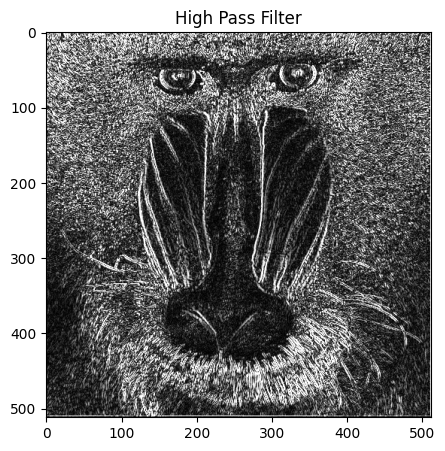

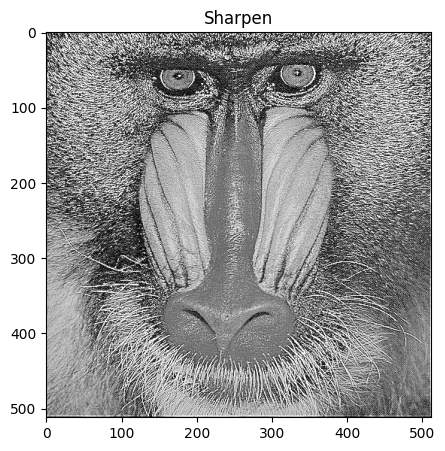

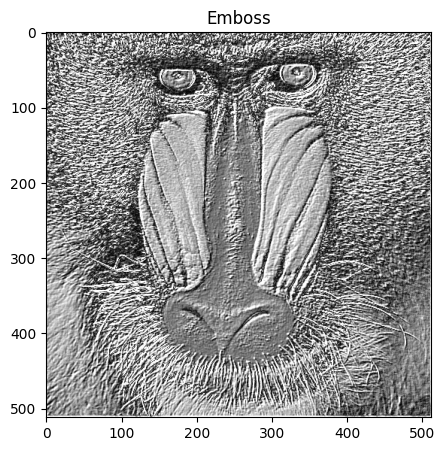

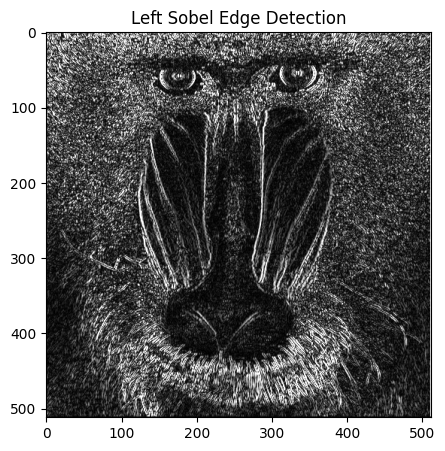

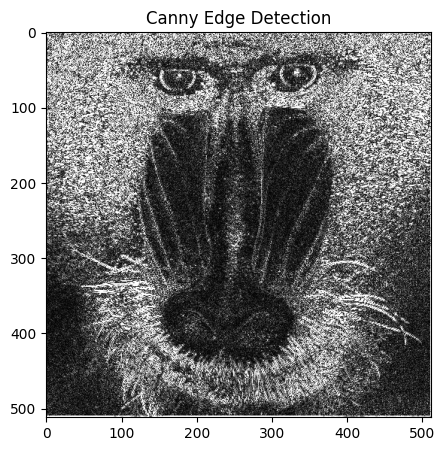

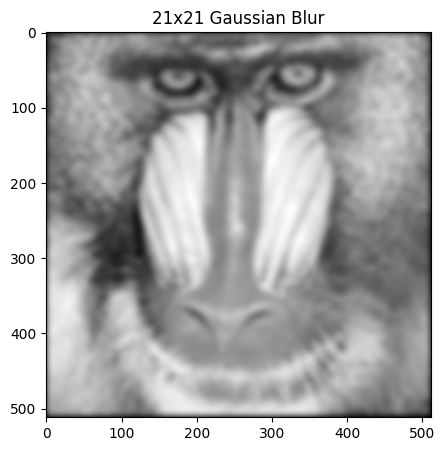

In [18]:
kernel_average  = np.ones((3,3)) / 9
kernel_lowpass  = np.array([[1,1,1],[1,4,1],[1,1,1]]) / 12
kernel_highpass = np.array([[-1,0,1],[-1,0,3],[-3,0,1]])
kernel_emboss   = np.array([[-2,-1,0],[-1,1,1],[0,1,2]])
kernel_sobel    = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
kernel_canny    = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]])

kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()

semua = [("Average Filter", kernel_average, 1),
         ("Low Pass Filter", kernel_lowpass, 1),
         ("High Pass Filter", kernel_highpass, 1),
         ("Sharpen", kernel_sharpen, 1),
         ("Emboss", kernel_emboss, 1),
         ("Left Sobel Edge Detection", kernel_sobel, 1),
         ("Canny Edge Detection", kernel_canny, 1),
         ("21x21 Gaussian Blur", gauss_kernel, 10)]

for nama, k, pad in semua:
    h = convolution2d(img_gray, k, 1, pad)
    plt.figure(figsize=(5,5))
    plt.imshow(np.clip(np.abs(h), 0, 255), cmap='gray')
    plt.title(nama)
    plt.show()

E. FILTER LIBRARY DAN FILTER MODERN

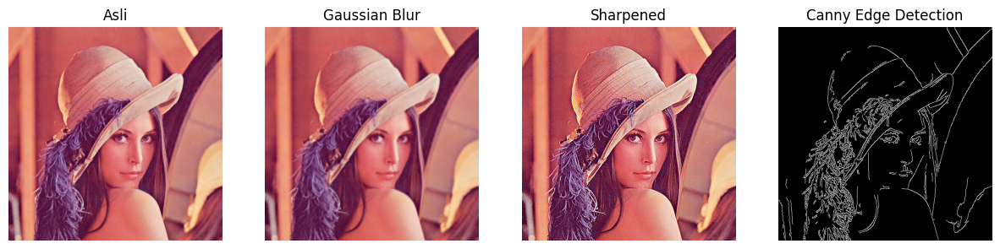

In [20]:
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread(DIR + "lena.png")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

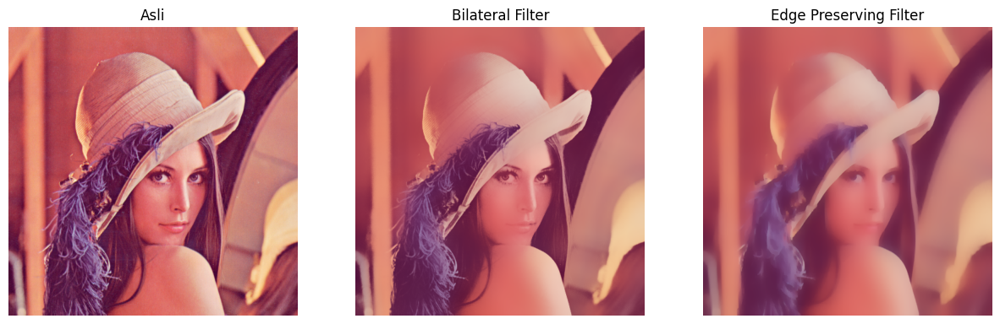

In [21]:
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

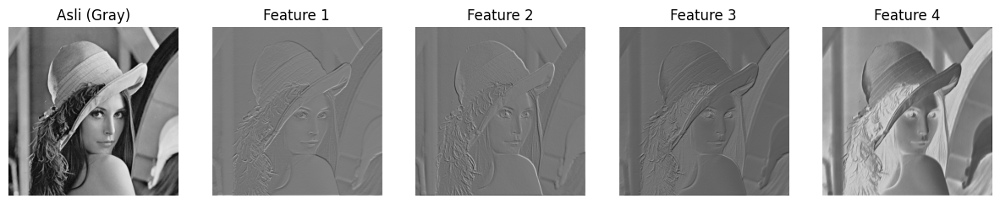

In [22]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

**Kesimpulan:** setiap kali dijalankan, feature map berbeda karena bobot kernel CNN diisi acak. Tiap feature map adalah hasil konvolusi 3x3 ada yang menonjolkan tepi, ada yang menghaluskan. Bedanya dengan filter manual: kernel CNN dipelajari lewat training, bukan ditentukan manusia.

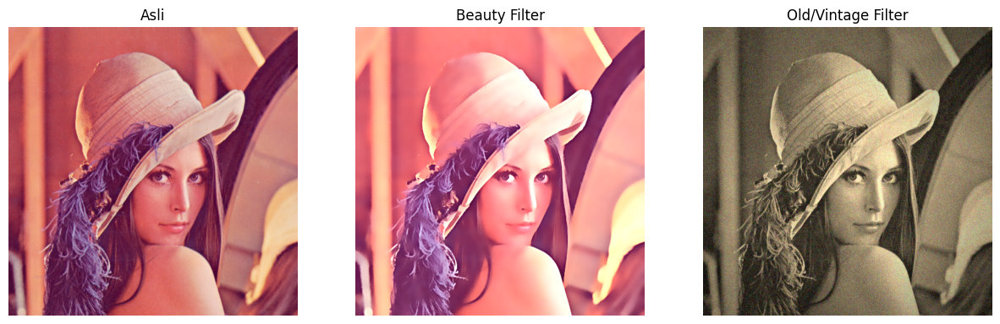

In [23]:
# 1. Beauty Filter
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# 2. Old/Vintage Filter
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])

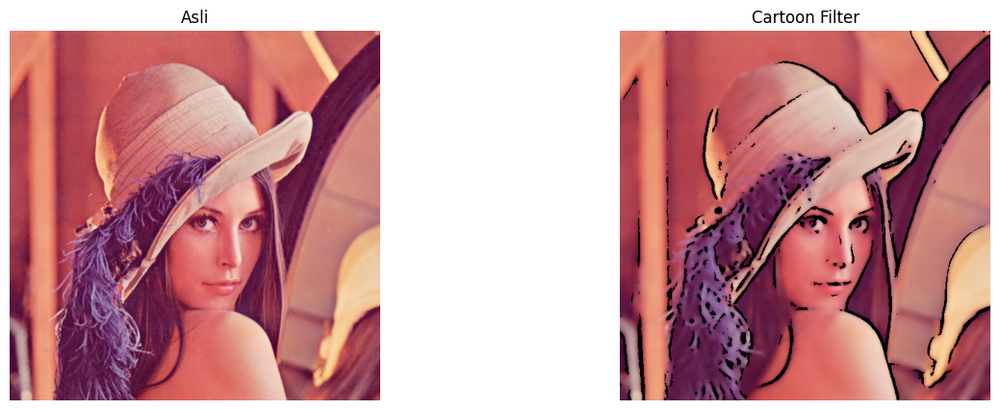

In [24]:
#Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

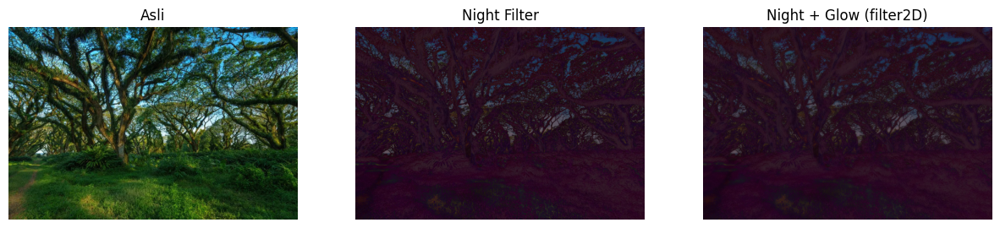

In [25]:
#Night Filter
img = cv.imread(DIR + "djawatan.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

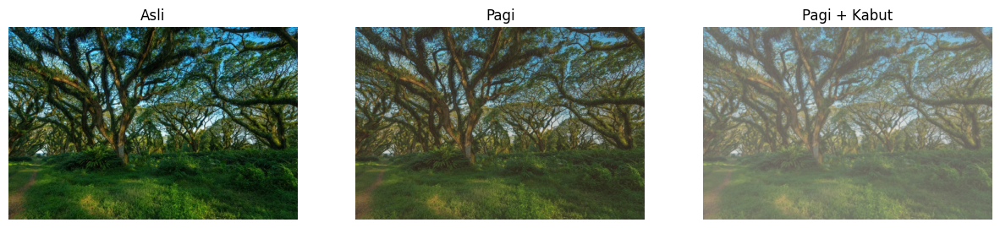

In [26]:
#Filter Suasana pagi dan Kabut
# Step 1: Kurangi kontras & cerahkan
alpha = 0.9  # contrast
beta = 20    # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# Step 2: Tambahkan warm tone (kemerahan / oranye)
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut], ["Asli", "Pagi", "Pagi + Kabut"])

# Tugas Praktikum

1. Tugas Analisis: Perbandingan Mean Filter (Blur Biasa) vs. Median Filter pada Noise “Salt and
Pepper”

a. Tambahkan noise bintik hitam-putih (Salt and Pepper) ke sebuah citra keabuan (grayscale).

b. Terapkan Mean Filter(3 x 3) dan Median Filter (3 x 3).
Pengolahan Citra dan Visi Komputer – Jurusan Teknologi Informasi

c. Amati dan analisis secara visual mengapa Median Filter jauh lebih bersih dalam menghapus
noise tersebut dibanding Mean Filter.

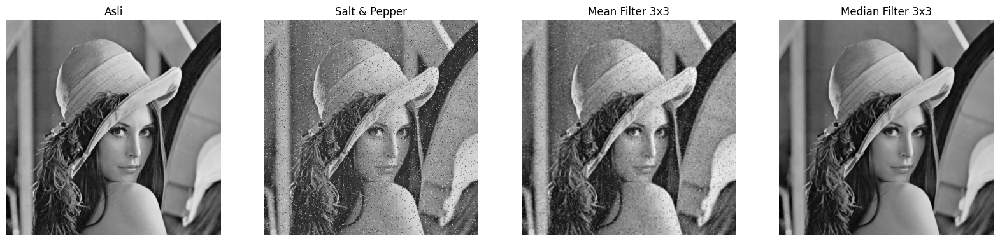

In [28]:
gray = cv.cvtColor(cv.imread(DIR + "lena.png"), cv.COLOR_BGR2GRAY)

# a) Tambah noise salt & pepper (5% piksel)
noisy = gray.copy()
acak = np.random.rand(*gray.shape)
noisy[acak < 0.025] = 0      # pepper (hitam)
noisy[acak > 0.975] = 255    # salt (putih)

# b) Mean Filter 3x3 dan Median Filter 3x3
mean_f = cv.blur(noisy, (3,3))
median_f = cv.medianBlur(noisy, 3)

show_side_by_side([gray, noisy, mean_f, median_f],
                  ["Asli", "Salt & Pepper", "Mean Filter 3x3", "Median Filter 3x3"], figsize=(20,5))

**c) Analisis:** Mean Filter menghitung rata-rata piksel di jendela 3x3, jadi titik putih (255) atau hitam (0) yang ekstrem ikut menaikkan/menurunkan rata-rata. Noise tidak hilang, hanya berubah menjadi bercak abu-abu dan gambar jadi kabur. Median Filter mengurutkan piksel lalu memakai nilai tengahnya. Titik ekstrem selalu ada di ujung urutan sehingga tidak terpilih, dan diganti nilai tetangga yang wajar. Karena itu hasilnya jauh lebih bersih dan tepi tetap tajam.

2. Tugas Evaluasi: Pemilihan Ukuran Kernel terbaik untuk Menajamkan Citra (Sharpening)

a. Buat kernel penajaman (Sharpening Kernel) ukuran 3 x 3 dan 5 x 5.

b. Terapkan pada citra yang sedikit buram (blurry).

c. Evaluasi hasilnya berdasarkan aspek Kejelasan Tepi vs. Kadar Noise/Noise Distortion yang
dihasilkan. Tentukan kernel mana yang paling optimal untuk digunakan sehari-hari

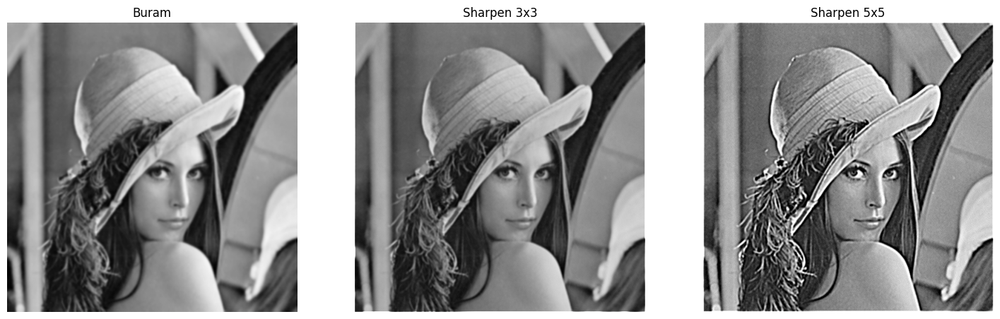

In [29]:
# a) Kernel penajaman
sharpen_3x3 = np.array([[0,-1,0],
                        [-1,5,-1],
                        [0,-1,0]])
sharpen_5x5 = np.array([[0,0,-1,0,0],
                        [0,-1,-2,-1,0],
                        [-1,-2,17,-2,-1],
                        [0,-1,-2,-1,0],
                        [0,0,-1,0,0]])

# b) Citra sedikit buram
buram = cv.GaussianBlur(gray, (0,0), 1.5)

hasil_3x3 = np.clip(convolution2d(buram, sharpen_3x3, 1, 1), 0, 255).astype(np.uint8)
hasil_5x5 = np.clip(convolution2d(buram, sharpen_5x5, 1, 2), 0, 255).astype(np.uint8)

show_side_by_side([buram, hasil_3x3, hasil_5x5],
                  ["Buram", "Sharpen 3x3", "Sharpen 5x5"], figsize=(18,6))

**c) Evaluasi:**
- **Kejelasan tepi:** 5x5 paling tajam, tetapi muncul garis terang-gelap (halo) di sekitar tepi. 3x3 tepinya tegas dan masih natural.
- **Noise:** 5x5 memperkuat noise jauh lebih besar (bobot tengah 17, dibanding 5 pada 3x3), sehingga butiran dan distorsi lebih terlihat.
- **Paling optimal untuk sehari-hari: 3x3.** Tepi sudah jelas, noise tidak berlebihan, dan hitungannya lebih ringan.

3. Tugas Kreasi: Filter Kartun Sederhana

a. Buatlah sebuah fungsi kustom bernama kartun(image) yang menggabungkan:
* Penghalusan warna menggunakan **Bilateral Filter** agar area warna menjadi rata.
* Deteksi garis tepi menggunakan **Adaptive Thresholding** atau **Canny Edge**.
* Penggabungan (kombinasi) keduanya menggunakan operasi logika/perkalian piksel.

b. Tampilkan hasil citra asli dengan citra efek kartun bersebelahan.

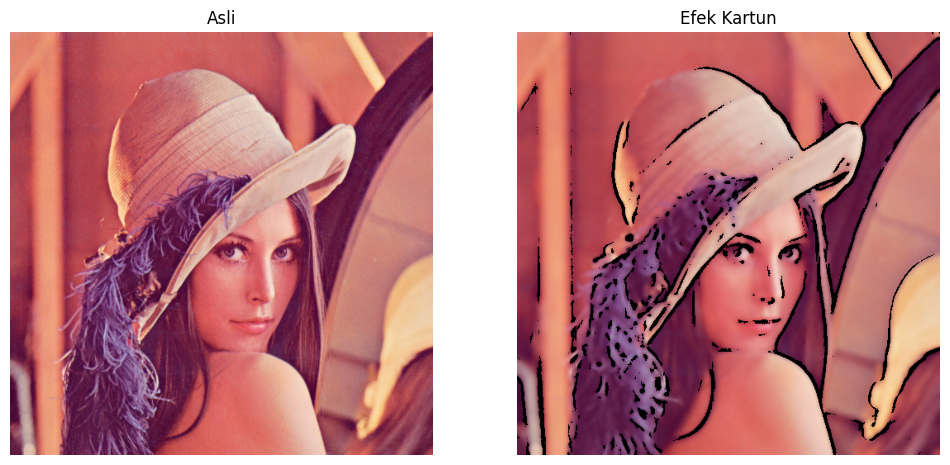

In [31]:
def kartun(image):
    # Penghalusan warna dengan Bilateral Filter
    warna = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)

    # Deteksi garis tepi dengan Adaptive Thresholding
    abu = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    abu = cv.medianBlur(abu, 7)
    garis = cv.adaptiveThreshold(abu, 255, cv.ADAPTIVE_THRESH_MEAN_C,
                                 cv.THRESH_BINARY, 9, 9)

    # Gabungkan keduanya dengan operasi logika AND
    return cv.bitwise_and(warna, warna, mask=garis)

img = cv.imread(DIR + "lena.png")
show_side_by_side([img, kartun(img)], ["Asli", "Efek Kartun"], figsize=(12,6))